# Bnpyro — Tutorial

**Bnpyro** is a Python library that compiles probabilistic programs into exact **Bayesian Networks** (BNs), using [pyAgrum](https://agrum.gitlab.io/) for BN structure and inference.

It implements the formal framework of the **λ!-calculus** from Faggian, Pautasso & Vanoni (POPL 2024):

| Bnpyro syntax | λ!-calculus |
|---|---|
| `bn.sample("x", Bernoulli(p))` | `let x = sample_d` |
| `bn.sample("x", bn.where(pa, ...))` | `let x = case⟨pa⟩` |
| `bn.thunk("f", dist)` | `let f = !t` |
| `f()` | `der f` |
| `bn.plate("s", N)` | Template BN |
| `bn.recurse("x", fn, N)` | `fix f N` |
| `bn.pair(x, y)` | `x ⊗ y` |
| `bn.letp(pair, lambda x, y: ...)` | `letp (x,y) = e in f` |

---

## Installation

```bash
pip install pyagrum pyro-ppl torch matplotlib
pip install scipy   # only for discretization_method=INTEGRATION
```

In [1]:
import sys, os
# Adjust path if needed
if os.path.basename(os.getcwd()) != 'src':
    sys.path.insert(0, 'src')

import torch
import matplotlib.pyplot as plt
import pyro.distributions as dist
from Bnpyro import BNContext, BNThunk, BNPair, MIDPOINT, INTEGRATION

C:\Users\louto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 1. Classic BN — Rain → Wet

The simplest case: two Boolean variables linked by a conditional probability table (CPT).

```
Rain  →  Wet
P(Rain=T)         = 0.2
P(Wet=T | Rain=T) = 0.7
P(Wet=T | Rain=F) = 0.01
```

`bn.where(condition, p_true, p_false)` encodes the conditional CPT.  
Corresponds to `let wet = case⟨rain⟩` in λ!-calculus.

In [2]:
bn1  = BNContext()
rain = bn1.sample("rain", dist.Bernoulli(0.2))
wet  = bn1.sample("wet",  bn1.where(rain, 0.7, 0.01))

bn1.show()


BN compilé : 2 noeuds, 1 arcs  [méthode=midpoint]
Nœuds : ['wet', 'rain']
Arcs  : [('rain', 'wet')]


In [3]:
# Exact inference: P(rain | wet=True)
p = bn1.query("rain", evidence={"wet": True})
print(f"P(rain | wet=True) = {p}")
print(f"  P(rain=True | wet=True) ≈ {p['True']:.3f}   (expected ≈ 0.946)")

P(rain | wet=True) = {'False': 0.05405405310164238, 'True': 0.9459459468983576}
  P(rain=True | wet=True) ≈ 0.946   (expected ≈ 0.946)


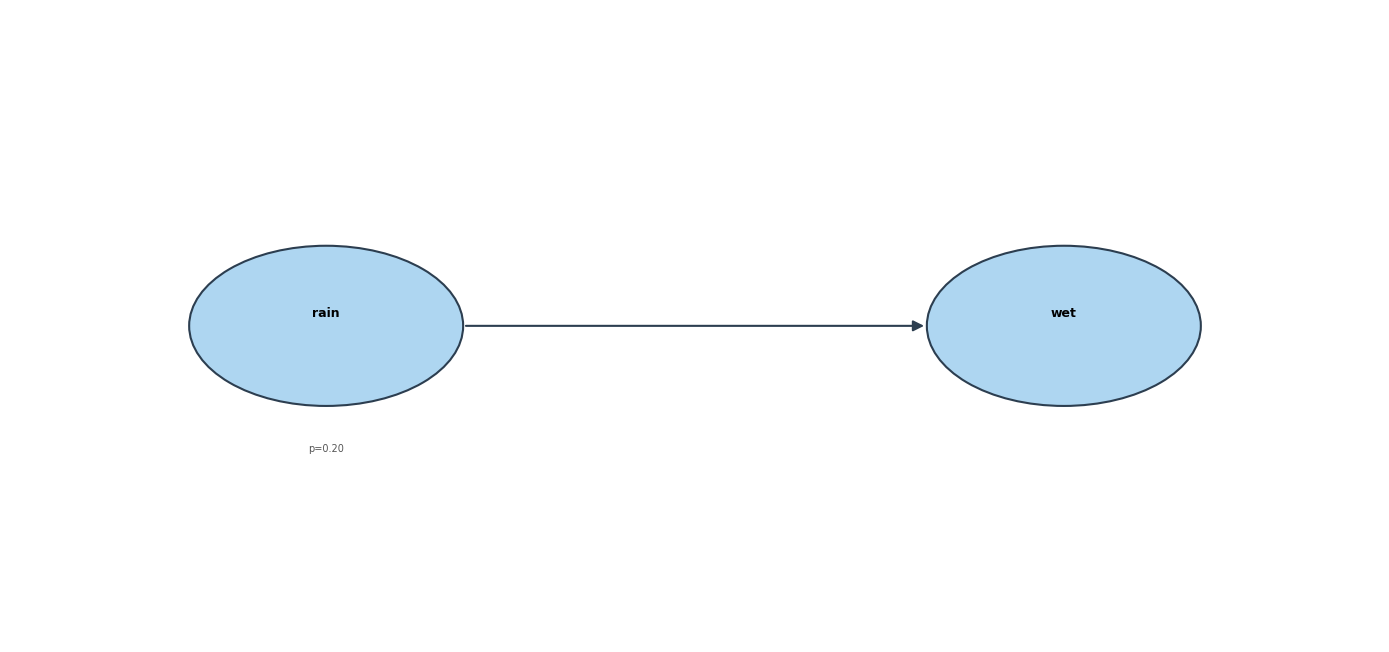

In [4]:
bn1.show_graph(show_cpt=True)


## 2. Thunk — shared biased coin (!)

**Problem**: flip the *same* biased coin *m* times — each flip must be an independent random variable, yet all share the same `bias` parameter.

In λ!-calculus:
```
let bias = sample_d       in
let coin = !(case⟨bias⟩)  in   ← ! = thunk (freeze)
let y1   = der coin        in   ← der = dereference (thaw)
let y2   = der coin
```

`bn.thunk()` **freezes** a distribution without creating a node.  
Each call `coin()` **thaws** it and creates a new independent node.

In [5]:
bn2  = BNContext()
bias = bn2.sample("bias", dist.Bernoulli(0.6))

# bn.thunk() = "!" : freeze the CPT without creating a node
coin = bn2.thunk("coin", bn2.where(bias, 0.8, 0.3))

# coin() = "der" : each call creates a new node
y1 = coin()   # → node "coin_1", parent = bias
y2 = coin()   # → node "coin_2", parent = bias (same CPT, distinct node)

bn2.show()


BN compilé : 3 noeuds, 2 arcs  [méthode=midpoint]
Nœuds : ['bias', 'coin_1', 'coin_2']
Arcs  : [('bias', 'coin_1'), ('bias', 'coin_2')]


In [6]:
# Two heads observed: update our belief about the bias
p2 = bn2.query("bias", evidence={"coin_1": True, "coin_2": True})
print(f"Prior       P(bias=True) = 0.6")
print(f"Posterior   P(bias=True | y1=T, y2=T) ≈ {p2['True']:.3f}")
print(f"  → two heads → evidence strongly favours high bias")

Prior       P(bias=True) = 0.6
Posterior   P(bias=True | y1=T, y2=T) ≈ 0.914
  → two heads → evidence strongly favours high bias


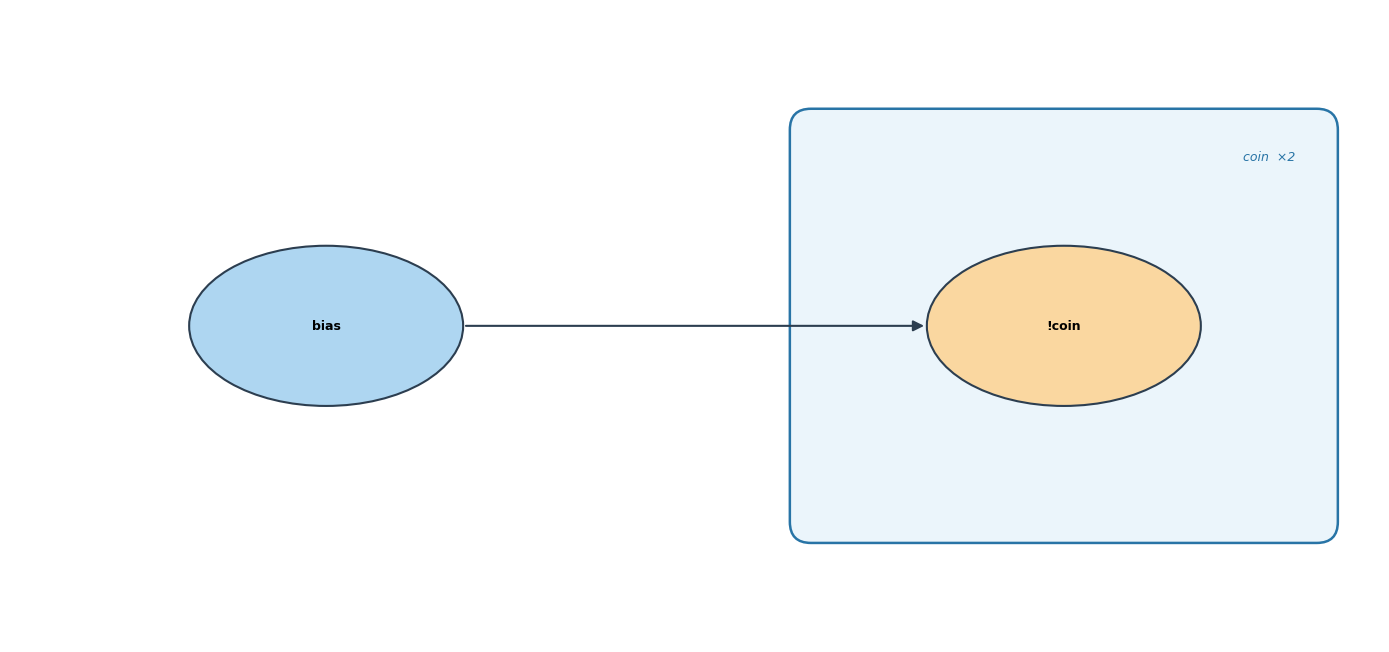

In [7]:
# Thunk-derived nodes are marked with "!" in the graph
# coin_1 and coin_2 are grouped into a virtual plate ×2
bn2.show_graph()


## 3. Continuous variables — automatic discretization

pyAgrum only supports discrete variables. Bnpyro automatically discretizes continuous distributions into `n_bins` equal-width intervals covering ~99% of the probability mass.

Bin probabilities are computed via the **CDF**:  `P(X in [a, b]) = F(b) − F(a)`  
If no CDF is available, a **Monte Carlo** fallback (10,000 samples + histogram) is used.

Supported out-of-the-box: `Normal`, `Beta`, `Gamma`, `Uniform`, `Exponential`, and any Pyro distribution.

In [8]:
bn3  = BNContext(n_bins=8)
temp = bn3.sample("temp",  dist.Normal(torch.tensor(20.0), torch.tensor(5.0)))
hum  = bn3.sample("humid", dist.Normal(torch.tensor(60.0), torch.tensor(10.0)))

bn3.show()


BN compilé : 2 noeuds, 0 arcs  [méthode=midpoint]
Nœuds : ['temp', 'humid']
Arcs  : []


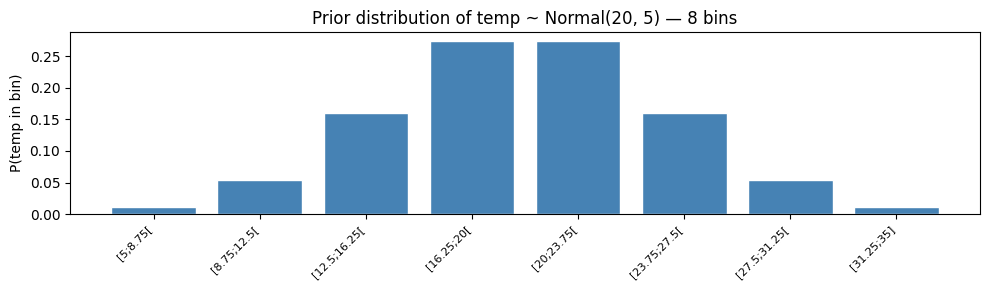

In [9]:
p3 = bn3.query("temp")

fig, ax = plt.subplots(figsize=(10, 3))
labels, values = list(p3.keys()), list(p3.values())
ax.bar(range(len(labels)), values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("P(temp in bin)")
ax.set_title("Prior distribution of temp ~ Normal(20, 5) — 8 bins")
plt.tight_layout()
plt.show()

### Choosing `n_bins`

More bins = better approximation, but CPT size grows as $n^{k+1}$ where $k$ is the number of continuous parents.

| Situation | Recommended `n_bins` |
|---|---|
| No continuous parents | 10 – 20 |
| 1 continuous parent | 10 – 15 |
| 2 continuous parents | 8 – 10 |
| 3+ continuous parents | 5 – 8 |

**Rule of thumb**: double `n_bins` and check if inference results stabilize.


## 4. Template BN — plate (N students)

`bn.plate(name, N)` repeats a BN structure N times with distinct nodes per iteration.  

`show_graph()` displays the **template view**: one representative node per role, wrapped in a ×N rectangle.

In [10]:
bn4  = BNContext()
diff = bn4.sample("difficulty", dist.Bernoulli(0.4))

for i in bn4.plate("student", 3):
    skill  = bn4.sample("skill", dist.Bernoulli(0.6))
    result = bn4.sample("result", bn4.where(skill,
        bn4.where(diff, 0.7, 0.95),  
        bn4.where(diff, 0.1, 0.3),   
    ))

bn4.show()


BN compilé : 7 noeuds, 6 arcs  [méthode=midpoint]
Nœuds : ['student_2/result', 'student_2/skill', 'difficulty', 'student_0/result', 'student_1/result', 'student_0/skill', 'student_1/skill']
Arcs  : [('student_0/skill', 'student_0/result'), ('difficulty', 'student_1/result'), ('student_1/skill', 'student_1/result'), ('difficulty', 'student_2/result'), ('difficulty', 'student_0/result'), ('student_2/skill', 'student_2/result')]


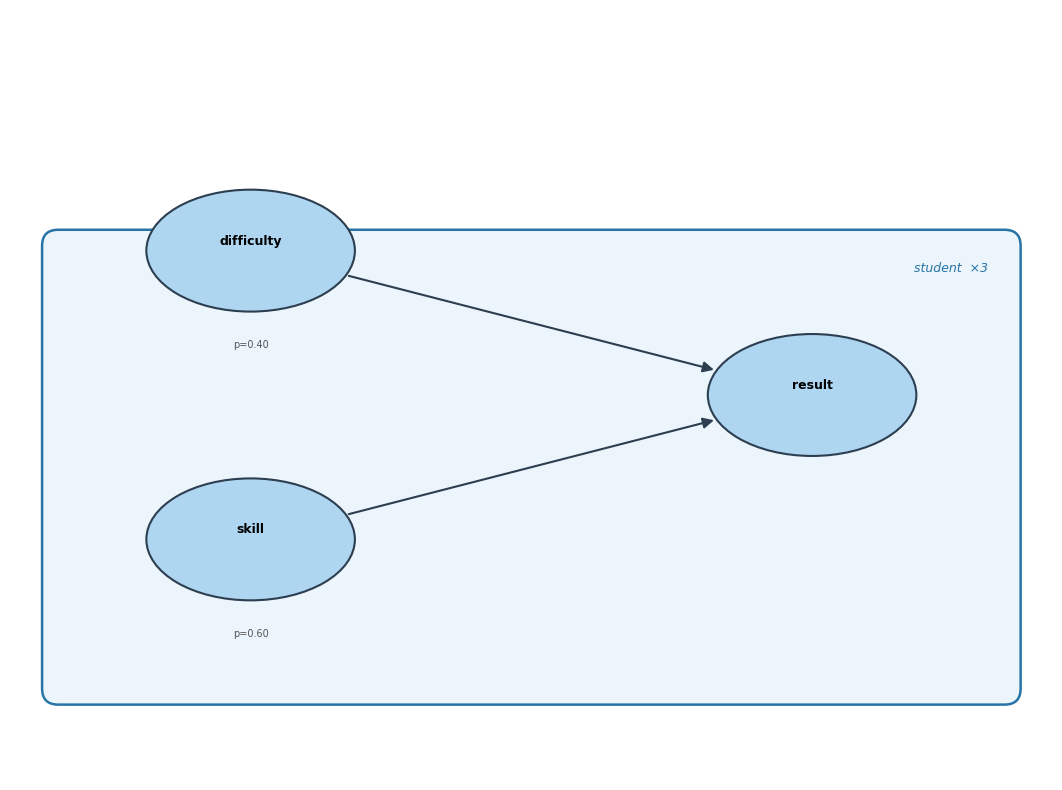

In [11]:
# Template view with plate notation
bn4.show_graph(show_cpt=True)

In [12]:
# Inference on the unrolled BN
# Evidence uses full node names: "plate_i/node"
p4 = bn4.query("difficulty", evidence={
    "student_0/result": True,
    "student_1/result": True,
    "student_2/result": False,
})
print(f"P(difficulty | 2 successes, 1 failure) = {p4}")

P(difficulty | 2 successes, 1 failure) = {'False': 0.659574453352847, 'True': 0.3404255466471529}



## 5. Universal lambda — any parent/child type combination

To condition a node on parents of **any type** (discrete or continuous), use a **lambda**:

```python
bn.sample("x", lambda parent_val: dist.SomeDist(...), parents=[parent_node])
```

Bnpyro **probes the lambda's return type** and routes to the correct construction:
- Lambda → `Bernoulli`  → discrete binary node
- Lambda → `Categorical`→ discrete k-class node
- Lambda → anything else → continuous (discretized) node

### 5a. Continuous → Continuous : X ~ Normal(μ, 1) with μ ~ Normal(0, 1)

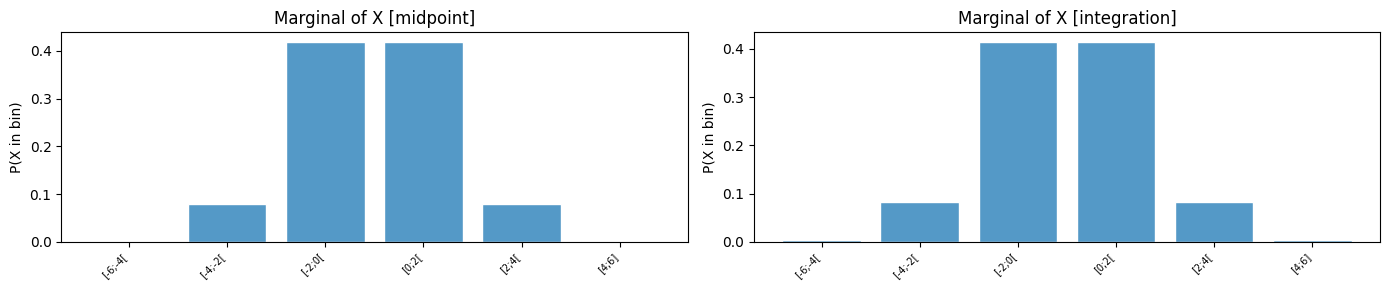

Both methods agree — INTEGRATION is more precise for coarse bins.


In [13]:
results = {}
for method in (MIDPOINT, INTEGRATION):
    bn5 = BNContext(n_bins=6, discretization_method=method)
    mu  = bn5.sample("mu", dist.Normal(0.0, 1.0))
    x   = bn5.sample("x",  lambda m: dist.Normal(m, 1.0), parents=[mu])
    results[method] = bn5.query("x")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for ax, method in zip(axes, (MIDPOINT, INTEGRATION)):
    p = results[method]
    ax.bar(range(len(p)), list(p.values()), color='#5499C7', edgecolor='white')
    ax.set_xticks(range(len(p)))
    ax.set_xticklabels(list(p.keys()), rotation=45, ha='right', fontsize=7)
    ax.set_title(f"Marginal of X [{method}]")
    ax.set_ylabel("P(X in bin)")
plt.tight_layout()
plt.show()
print("Both methods agree — INTEGRATION is more precise for coarse bins.")

### 5b. Continuous → Bernoulli : coin ~ Bernoulli(bias) with bias ~ Uniform(0, 1)

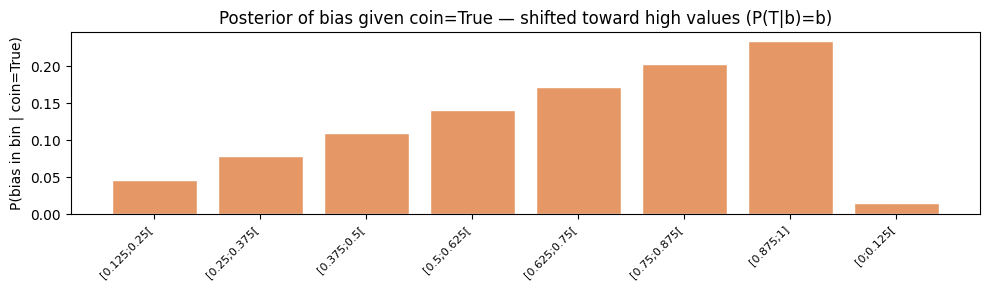

In [14]:
bn_cb = BNContext(n_bins=8)
bias  = bn_cb.sample("bias", dist.Uniform(torch.tensor(0.0), torch.tensor(1.0)))
coin  = bn_cb.sample("coin",
    lambda b: dist.Bernoulli(torch.tensor(b).clamp(0.01, 0.99)),
    parents=[bias]
)

# Posterior of bias given coin=True
p_cb = bn_cb.query("bias", evidence={"coin": True})

fig, ax = plt.subplots(figsize=(10, 3))
labels = sorted(p_cb.keys())
ax.bar(range(len(labels)), [p_cb[k] for k in labels], color='#E59866', edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("P(bias in bin | coin=True)")
ax.set_title("Posterior of bias given coin=True — shifted toward high values (P(T|b)=b)")
plt.tight_layout()
plt.show()

### 5c. Categorical → Continuous : val ~ Normal(cat×5, 1) with cat ~ Categorical

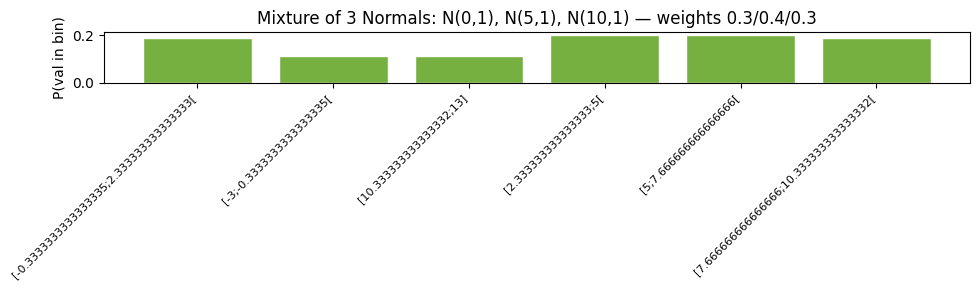

In [15]:
bn_cc = BNContext(n_bins=6)
cat   = bn_cc.sample("cat", dist.Categorical(torch.tensor([0.3, 0.4, 0.3])))
val   = bn_cc.sample("val",
    lambda c: dist.Normal(torch.tensor(c * 5.0), torch.tensor(1.0)),
    parents=[cat]
)

p_cc = bn_cc.query("val")

fig, ax = plt.subplots(figsize=(10, 3))
labels = sorted(p_cc.keys())
ax.bar(range(len(labels)), [p_cc[k] for k in labels], color='#76B041', edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("P(val in bin)")
ax.set_title("Mixture of 3 Normals: N(0,1), N(5,1), N(10,1) — weights 0.3/0.4/0.3")
plt.tight_layout()
plt.show()


## 6. Multi-parent discrete — nested bn.where

For a Bernoulli node conditioned on **multiple discrete parents**, nest `bn.where` calls:

```python
wet = bn.sample("wet", bn.where(rain,
    bn.where(sprinkler, 0.99, 0.90),   # rain=True branch
    bn.where(sprinkler, 0.80, 0.01),   # rain=False branch
))
```

This encodes the **Wet Grass** CPT from Darwiche (2009).

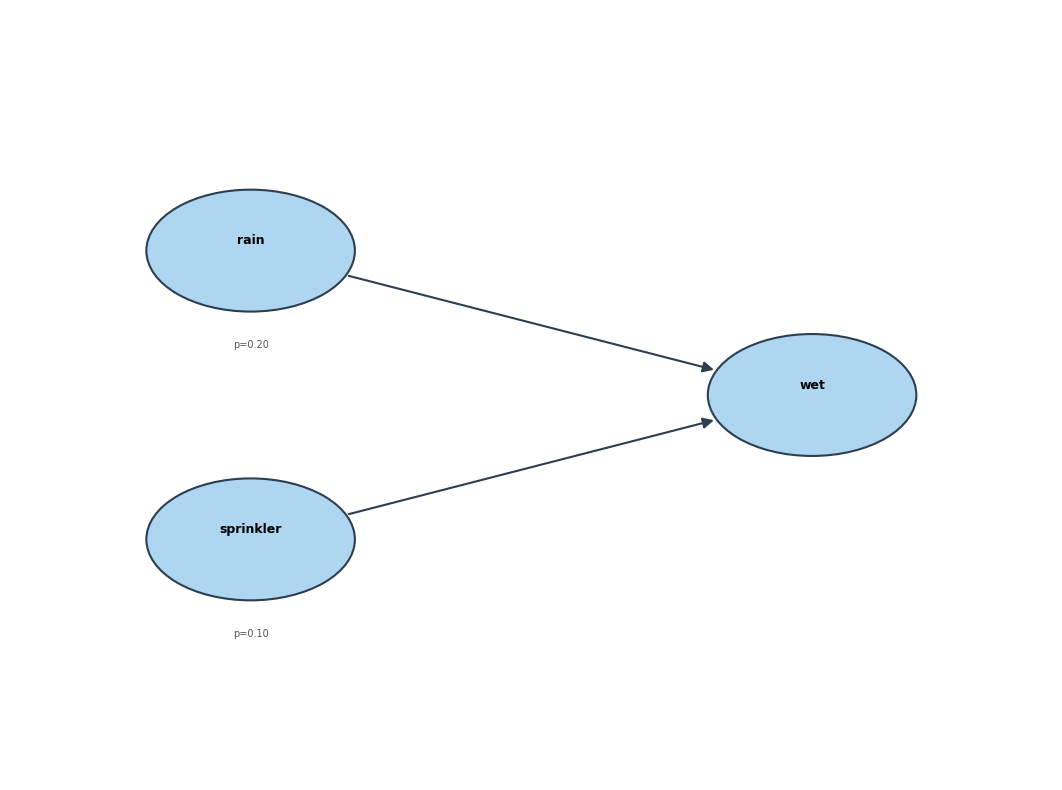

In [16]:
bn6  = BNContext()
rain = bn6.sample("rain",      dist.Bernoulli(0.2))
spr  = bn6.sample("sprinkler", dist.Bernoulli(0.1))
wet  = bn6.sample("wet", bn6.where(rain,
    bn6.where(spr, 0.99, 0.90),   # rain=True
    bn6.where(spr, 0.80, 0.01),   # rain=False
))

bn6.show_graph(show_cpt=True)

In [17]:
p_rain = bn6.query("rain",      evidence={"wet": True})
p_spr  = bn6.query("sprinkler", evidence={"wet": True})

print(f"P(rain=True      | wet=True) = {p_rain['True']:.3f}")
print(f"P(sprinkler=True | wet=True) = {p_spr['True']:.3f}")
print()
print("Rain is more likely than sprinkler because P(rain) > P(sprinkler).")

P(rain=True      | wet=True) = 0.719
P(sprinkler=True | wet=True) = 0.331

Rain is more likely than sprinkler because P(rain) > P(sprinkler).



## 7. Recursion — fix combinator

The **fix** (fixed-point) combinator encodes recursive programs. In λ!-calculus, a Markov chain of length n is written:

```
let chain = fix(λself. λn.
  if n=0 then sample(Bernoulli(0.5))
  else let prev = self(n-1) in sample(case⟨prev⟩(0.9, 0.1))
)
```

`bn.recurse(name, step_fn, n_steps)` unrolls the fixed point `n_steps` times:
- `step_fn(i, None)` → base case (i=0, no parent yet)
- `step_fn(i, prev)` → step case (i>0, prev = last node)
- If `step_fn` returns a callable, it is called with `parents=[prev]` (for continuous parents)

The modeled problem :  

Imagine a system that evolves over time - for example:  

A machine with two states: Working (True) or Broken (False)  
Initial state: P($X_0$ = True) = 0.5 (equilibrium)

Transition rule:  
If it is working today → there is a 90% chance that it will remain working tomorrow  
If it is broken today → there is a 10% chance that it will become working tomorrow  


BN compilé : 4 noeuds, 3 arcs  [méthode=midpoint]
Nœuds : ['X_2', 'X_0', 'X_3', 'X_1']
Arcs  : [('X_0', 'X_1'), ('X_1', 'X_2'), ('X_2', 'X_3')]


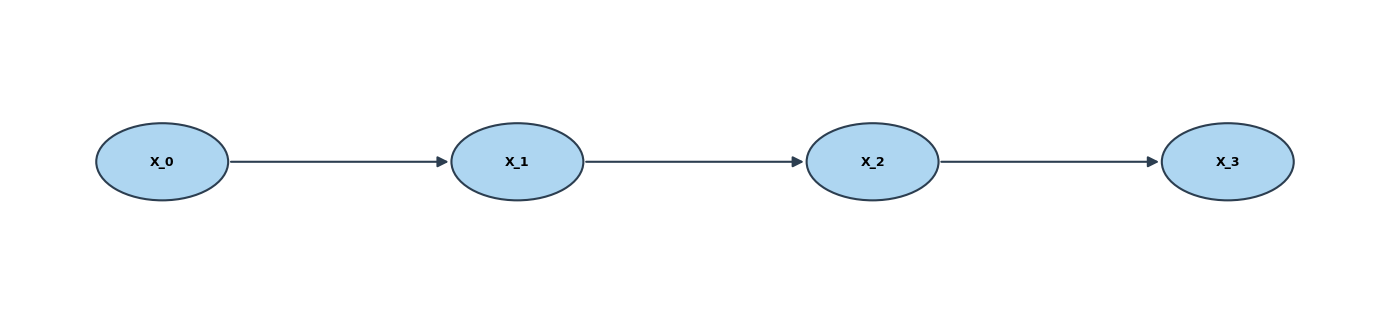

In [18]:
# 7a. Bernoulli Markov chain  X_0 → X_1 → X_2 → X_3
N    = 4
bn7a = BNContext()
states = bn7a.recurse("X",
    step_fn=lambda _, prev:
        dist.Bernoulli(0.5)           if prev is None   # base case: X_0 ~ Ber(0.5)
        else bn7a.where(prev, 0.9, 0.1),               # step:  X_t | X_{t-1}
    n_steps=N
)

bn7a.show()
bn7a.show_graph()

In [19]:
p7a = bn7a.query(f"X_{N-1}", evidence={"X_0": True})
print(f"P(X_{N-1}=True | X_0=True) = {p7a['True']:.3f}")
print(f"  Expected ≈ 0.9^{N-1} = {0.9**(N-1):.3f}  (small deviation due to discretization)")

P(X_3=True | X_0=True) = 0.756
  Expected ≈ 0.9^3 = 0.729  (small deviation due to discretization)



BN compilé : 4 noeuds, 3 arcs  [méthode=midpoint]
Nœuds : ['pos_2', 'pos_1', 'pos_3', 'pos_0']
Arcs  : [('pos_0', 'pos_1'), ('pos_1', 'pos_2'), ('pos_2', 'pos_3')]


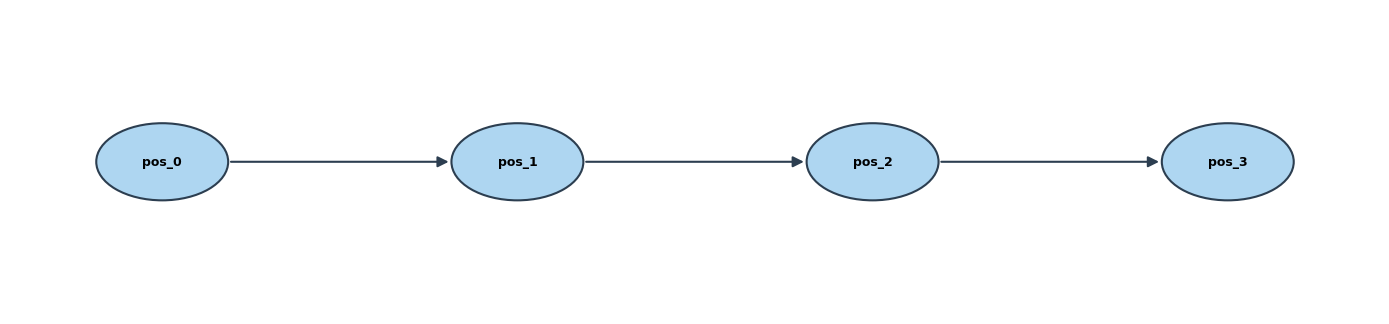

In [20]:
# 7b. Gaussian random walk  pos_t | pos_{t-1} ~ Normal(pos_{t-1}, 0.5)
bn7b = BNContext(n_bins=8)
traj = bn7b.recurse("pos",
    step_fn=lambda _, prev:
        dist.Normal(0.0, 1.0)                  if prev is None   # base: pos_0 ~ N(0,1)
        else (lambda p: dist.Normal(p, 0.5)),                    # step: pos_t | pos_{t-1}
    n_steps=4
)

bn7b.show()
bn7b.show_graph()

## 8. Higher-order functions

The λ!-calculus supports **higher-order programs** — functions that take functions (or thunks) as arguments.  
In Bnpyro, Python functions over `BNNode` and `BNThunk` objects naturally encode these patterns.

### 8a. Parametric thunk `!(λb. Bernoulli(b))` — thunk depending on a parent

A **parametric thunk** freezes a lambda + parents. Each dereference creates a new node with the same CPT.


BN compilé : 3 noeuds, 2 arcs  [méthode=midpoint]
Nœuds : ['bias', 'coin_1', 'coin_2']
Arcs  : [('bias', 'coin_1'), ('bias', 'coin_2')]


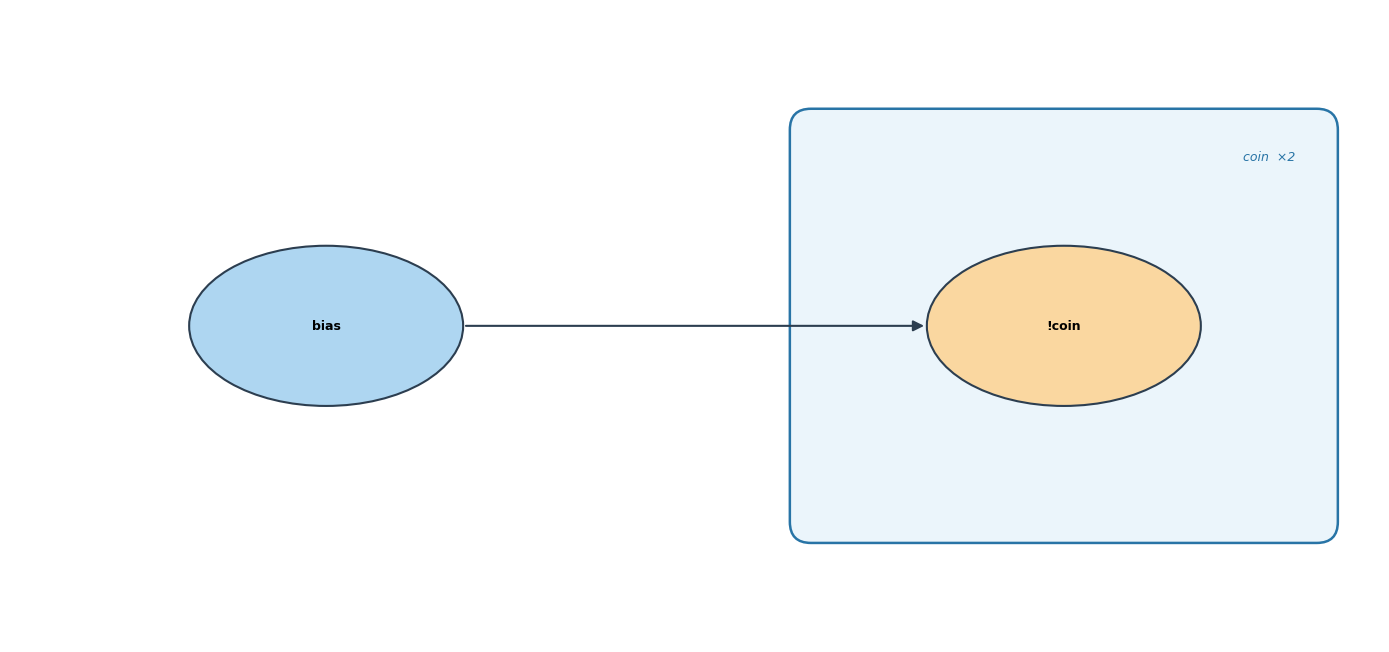

P(bias > 0.5 | 2 heads) = 0.757


In [21]:
# let coin = !(λb. Bernoulli(b))  —  higher-order thunk
bn8a  = BNContext(n_bins=8)
bias  = bn8a.sample("bias", dist.Uniform(torch.tensor(0.0), torch.tensor(1.0)))

# Parametric thunk: the frozen distribution depends on `bias`
coin  = bn8a.thunk("coin",
    lambda b: dist.Bernoulli(torch.tensor(b).clamp(0.01, 0.99)),
    parents=[bias]
)

y1 = coin()   # coin_1 ~ Bernoulli(bias)
y2 = coin()   # coin_2 ~ Bernoulli(bias) — new node, same CPT

bn8a.show()
bn8a.show_graph()

p8a = bn8a.query("bias", evidence={"coin_1": True, "coin_2": True})
p_high = sum(v for k, v in p8a.items() if float(k.split(';')[0].strip('[')) > 0.5)
print(f"P(bias > 0.5 | 2 heads) = {p_high:.3f}")

### 8b. HOF taking a BNThunk — `apply_n : !A → N → Aⁿ`


BN compilé : 3 noeuds, 0 arcs  [méthode=midpoint]
Nœuds : ['fair_3', 'fair_2', 'fair_1']
Arcs  : []


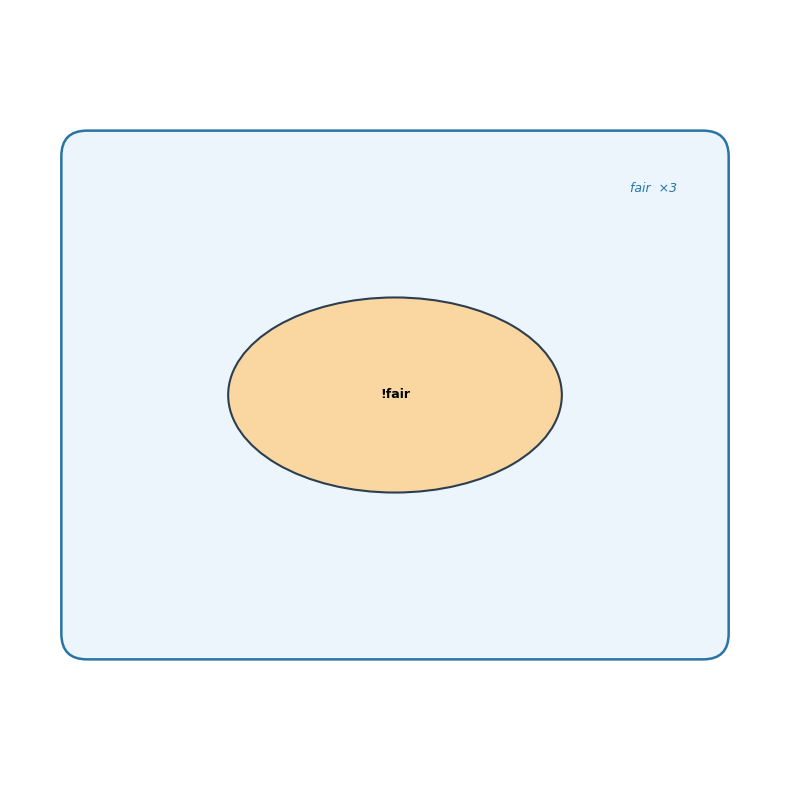

Created nodes: ['fair_1', 'fair_2', 'fair_3']


In [22]:
def apply_n(thunk: BNThunk, n: int) -> list:
    """Higher-order function: dereferences a thunk n times. apply_n : !A → N → Aⁿ"""
    return [thunk() for _ in range(n)]

bn8b  = BNContext()
fair  = bn8b.thunk("fair", dist.Bernoulli(0.5))
flips = apply_n(fair, 3)   # 3 independent fair coin flips

bn8b.show()
bn8b.show_graph()
print(f"Created nodes: {[n.name for n in flips]}")

### 8c. Reusable BN constructor — `λsignal. sample("sensor", N(signal, 0.2))`

A Python function taking `BNNode` arguments and returning a `BNNode` is a higher-order BN constructor.


BN compilé : 3 noeuds, 2 arcs  [méthode=midpoint]
Nœuds : ['obs2', 'obs1', 'signal']
Arcs  : [('signal', 'obs1'), ('signal', 'obs2')]


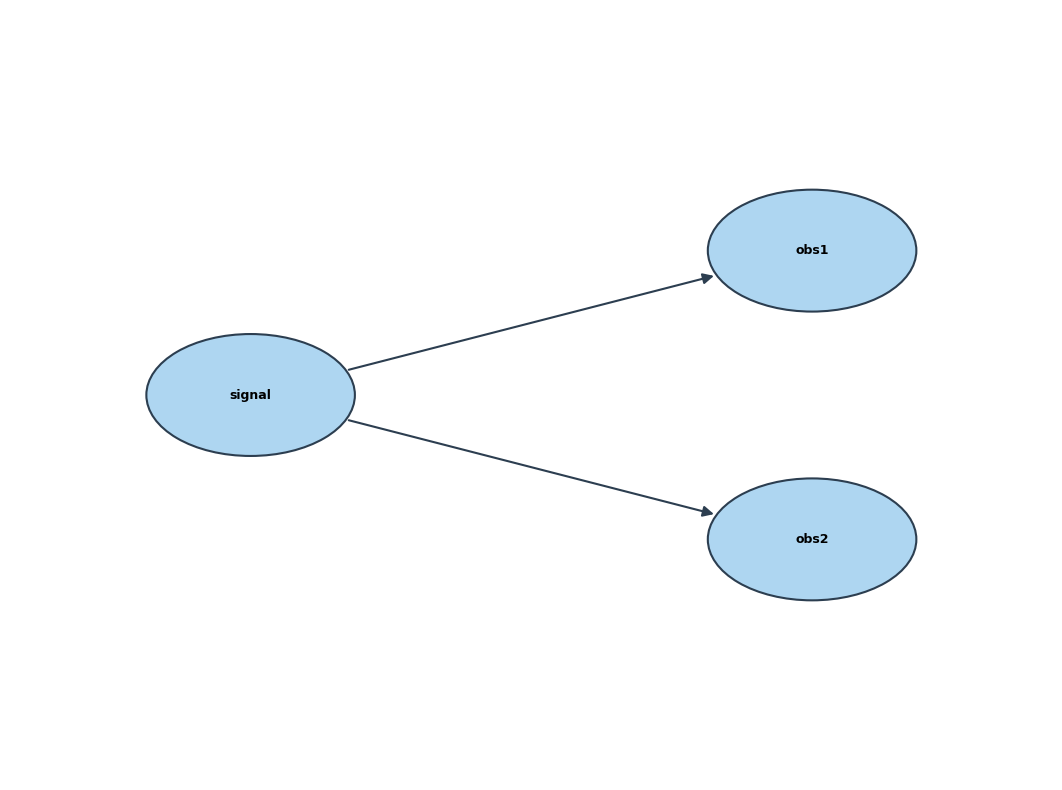

P(signal | obs1>0, obs2>0):
  [-1;0[               : 0.000
  [-2;-1[              : 0.000
  [-3;-2[              : 0.000
  [0;1[                : 0.998
  [1;2[                : 0.002
  [2;3]                : 0.000


In [23]:
def make_sensor(bn_ctx: BNContext, signal_node, name: str):
    """Reusable pattern: noisy sensor reading a continuous signal.
    Corresponds to: λsignal. sample("sensor", Normal(signal, 0.2))
    """
    return bn_ctx.sample(name, lambda s: dist.Normal(s, 0.2), parents=[signal_node])

bn8c   = BNContext(n_bins=6)
signal = bn8c.sample("signal", dist.Normal(0.0, 1.0))
obs1   = make_sensor(bn8c, signal, "obs1")   # first sensor
obs2   = make_sensor(bn8c, signal, "obs2")   # second sensor (same pattern, new node)

bn8c.show()
bn8c.show_graph()

# Evidence on continuous nodes uses bin index (integer)
p8c = bn8c.query("signal", evidence={"obs1": 3, "obs2": 3})  # bin 3 = positive half
print("P(signal | obs1>0, obs2>0):")
for k, v in sorted(p8c.items()):
    print(f"  {k:20s} : {v:.3f}")


## 9. Pairs and letp — tensor type $\otimes$

In λ!-calculus, the **tensor product** `L ⊗ K` represents a pair of random variables.

- **Introduction**: `(t, u)` → `bn.pair(node1, node2)` → `BNPair`
- **Elimination**: `letp (x,y) = e in f(x,y)` → `bn.letp(pair, lambda x, y: f(x, y))`

**Note**: pyAgrum has no tuple-valued nodes, so `BNPair` is a structured container for two existing nodes. Python tuple destructuring `x, y = pair` is equivalent to `bn.letp`.

weather = (rain, wind)

BN compilé : 3 noeuds, 2 arcs  [méthode=midpoint]
Nœuds : ['wind', 'wet', 'rain']
Arcs  : [('rain', 'wet'), ('wind', 'wet')]


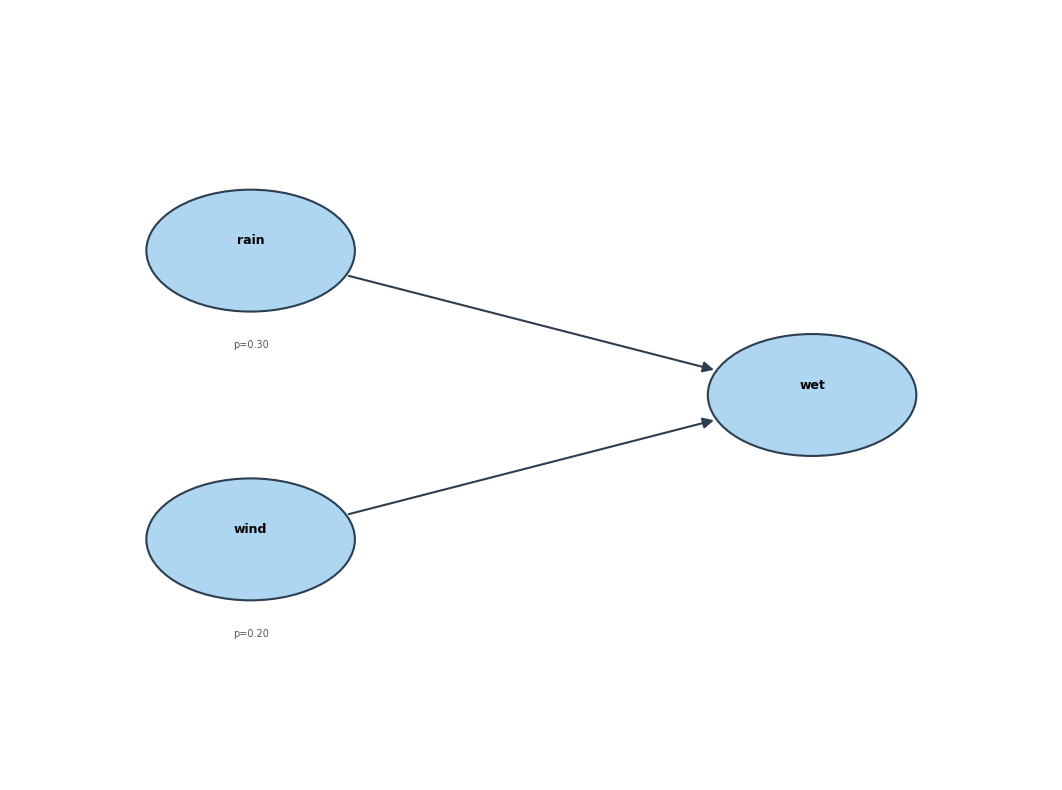

In [24]:
bn9  = BNContext()
rain = bn9.sample("rain", dist.Bernoulli(0.3))
wind = bn9.sample("wind", dist.Bernoulli(0.2))

# ⊗-introduction: create a pair  (rain, wind) : B ⊗ B
weather = bn9.pair(rain, wind)
print(f"weather = {weather}")

# ⊗-elimination (letp): destructure and use both components
# letp (r, w) = weather in sample("wet", case⟨r⟩(...))
wet = bn9.letp(weather, lambda r, w:
    bn9.sample("wet", bn9.where(r,
        bn9.where(w, 0.99, 0.90),
        bn9.where(w, 0.70, 0.01),
    ))
)

bn9.show()
bn9.show_graph(show_cpt=True)

In [25]:
p9 = bn9.query("rain", evidence={"wet": True})
print(f"P(rain=True | wet=True) = {p9['True']:.3f}")

# Python destructuring IS letp
r2, w2 = weather
print(f"\nDestructuring:  r2={r2.name}, w2={w2.name}  (same nodes as rain, wind)")

P(rain=True | wet=True) = 0.727

Destructuring:  r2=rain, w2=wind  (same nodes as rain, wind)



## 10. Factor semantics

The **factor semantics** of the λ!-calculus assigns to each BN the joint probability decomposition:

$$P(X_1 = x_1, \ldots, X_n = x_n) = \prod_{i=1}^{n} P(X_i = x_i \mid \mathrm{pa}(X_i))$$

Each CPT is one **factor**. Variable Elimination (VE) computes marginals by summing out variables from this product — which corresponds to β-reduction in the λ!-calculus.

Bnpyro exposes three methods:
- `bn.prob(assignment)` — evaluate the joint at a specific point
- `bn.log_prob(assignment)` — log-space version (numerically stable)
- `bn.evidence_prob(evidence)` — marginal P(evidence), via VE (pyAgrum)

In [26]:
bn10  = BNContext()
rain  = bn10.sample("rain", dist.Bernoulli(0.2))
wet   = bn10.sample("wet",  bn10.where(rain, 0.9, 0.01))

# --- bn.prob : direct factor product ---
# P(rain=T, wet=T) = P(rain=T) × P(wet=T|rain=T) = 0.2 × 0.9 = 0.18
p_tt = bn10.prob({"rain": True,  "wet": True})
p_ff = bn10.prob({"rain": False, "wet": False})
print(f"bn.prob(rain=T, wet=T) = {p_tt:.4f}   expected: 0.2 × 0.9 = {0.2*0.9:.4f}")
print(f"bn.prob(rain=F, wet=F) = {p_ff:.4f}   expected: 0.8 × 0.99 = {0.8*0.99:.4f}")

# Sanity check: all joint probabilities sum to 1
total = sum(
    bn10.prob({"rain": r, "wet": w})
    for r in (True, False) for w in (True, False)
)
print(f"Sum of all joint probs = {total:.6f}   (should be 1.0)")

bn.prob(rain=T, wet=T) = 0.1800   expected: 0.2 × 0.9 = 0.1800
bn.prob(rain=F, wet=F) = 0.7920   expected: 0.8 × 0.99 = 0.7920
Sum of all joint probs = 1.000000   (should be 1.0)


In [27]:
# --- bn.log_prob ---
import math
lp = bn10.log_prob({"rain": True, "wet": True})
print(f"bn.log_prob(rain=T, wet=T) = {lp:.4f}   = log({p_tt:.4f}) = {math.log(p_tt):.4f}")

bn.log_prob(rain=T, wet=T) = -1.7148   = log(0.1800) = -1.7148


In [28]:
# --- bn.evidence_prob : marginal P(evidence) via Variable Elimination ---
# P(wet=True) = P(rain=T)×P(wet=T|rain=T) + P(rain=F)×P(wet=T|rain=F)
#             = 0.2×0.9 + 0.8×0.01 = 0.188
p_e_t = bn10.evidence_prob({"wet": True})
p_e_f = bn10.evidence_prob({"wet": False})
expected = 0.2*0.9 + 0.8*0.01
print(f"bn.evidence_prob(wet=True)  = {p_e_t:.4f}   expected: {expected:.4f}")
print(f"bn.evidence_prob(wet=False) = {p_e_f:.4f}")
print(f"Sum                         = {p_e_t + p_e_f:.6f}   (should be 1.0)")

bn.evidence_prob(wet=True)  = 0.1880   expected: 0.1880
bn.evidence_prob(wet=False) = 0.8120
Sum                         = 1.000000   (should be 1.0)


In [29]:
# --- Bayes Factor: compare two models ---
# M1: P(rain) = 0.2   vs   M2: P(rain) = 0.5
bn_m1 = BNContext()
r1    = bn_m1.sample("rain", dist.Bernoulli(0.2))
w1    = bn_m1.sample("wet",  bn_m1.where(r1, 0.9, 0.01))

bn_m2 = BNContext()
r2    = bn_m2.sample("rain", dist.Bernoulli(0.5))
w2    = bn_m2.sample("wet",  bn_m2.where(r2, 0.9, 0.01))

pe_m1 = bn_m1.evidence_prob({"wet": True})
pe_m2 = bn_m2.evidence_prob({"wet": True})
K     = pe_m1 / pe_m2

print(f"P(wet=T | M1) = {pe_m1:.4f}   [P(rain)=0.2]")
print(f"P(wet=T | M2) = {pe_m2:.4f}   [P(rain)=0.5]")
print(f"Bayes Factor K = {K:.3f}")
print(f"  → M2 is {1/K:.1f}× more plausible given wet=True")

P(wet=T | M1) = 0.1880   [P(rain)=0.2]
P(wet=T | M2) = 0.4550   [P(rain)=0.5]
Bayes Factor K = 0.413
  → M2 is 2.4× more plausible given wet=True
